# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leann Vo

**Date:** 9/2/2026

In [160]:
# #1: Cleaning Price Variable

# Load the airbnb data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('./airbnb_hw.csv')

# Look at the data
print("df.shape: num rows, col")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes['Price'], '\n')
# Price was object dtype, needs to be cleaned/changed to numerical

# Diagnose dirty variable
var = 'Price'
print(df[var].unique(), '\n')

# Prices above 999 have commas that need to be cleaned

df.shape: num rows, col
(30478, 13) 

df.dtypes:
object 

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1,200' '158' '650' '234' '310' '695' '400' 

In [161]:
# Clean numerical variable
print('Before coercion:\n', df[var].describe(), '\n')
df[var] = df[var].str.replace(',', '') # removes commas
df[var] = pd.to_numeric(df[var], errors='coerce') # changes to numeric
df['Price_nan'] = df[var].isnull()
print('After coercion:\n', df[var].describe(), '\n')
print('Total missings:\n', sum(df['Price_nan']))
print(df[var].unique(), '\n')

# I ended up with 0 missing values. I removed the commas from the Price values that were above 999 and converted the column from object to numeric.

Before coercion:
 count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object 

After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missings:
 0
[  145    37    28   199   549   149   250    90   270   290   170    59
    49    68   285    75   100   150   700   125   175    40    89    95
    99   499   120    79   110   180   143   230   350   135    85    60
    70    55    44   200   165   115    74    84   129    50   185    80
   190   140    45    65   225   600   109  1990    73   240    72   105
   155   160    42   132   117   295   280   159   107    69   239   220
   399   130   375   585   275   139   260    35   133   300   289   179
    98   195    29    27    39   249   192   142   169  1000   131   138
   113   122   329   101   475   238   272   308   126   235   

In [162]:
# #2: Minnesota Data Variables
df = pd.read_csv('./mn_police_use_of_force.csv')

# Look at the data
print("df.shape: num rows, col")
print(df.shape, '\n')

print("df.dtypes: col types")
print(df.dtypes, '\n')

df.head()

# Diagnose dirty variable
var = 'subject_injury'
print(df[var].unique(), '\n') # need to fix nan
print(df[var].value_counts(), '\n')

df.shape: num rows, col
(12925, 13) 

df.dtypes: col types
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 



In [163]:
# Clean Categorical variable
df[var] = df[var].replace('', np.nan)
# print(df[var].unique(), '\n')
# print(df[var].value_counts(dropna=False), '\n')

df_cleaned = df.dropna(subset=[var])
# print(df_cleaned[var].unique(), '\n')

# df_cleaned.head()

# Count missing values
print('Missing values:', df[var].isnull().sum())

# print('Missing values after cleaning:', df_cleaned[var].isnull().sum())

# Find proportion of missing values
missing_val = df[var].isnull().mean()
print('Proportion missing:', missing_val)
# print('Percent missing:', missing_val*100)

# Cross-tabulate subject_injury and force_type
cross_tab = pd.crosstab(df['subject_injury'], df['force_type'],dropna=False)
# print(cross_tab)
cross_tab_prop = cross_tab / cross_tab.sum(axis=0)
# print(cross_tab_prop)

Missing values: 9848
Proportion missing: 0.7619342359767892


About 76.2% of the subject_injury values were missing. This is definitely a concern since over half of the data doesn't have any injury information. Using the cross-tab, I found that the majority of missing values varied based on the force type. Bodily Force, Taser, and Chemical Irritant cases have at least 70% missing subject_injury values while other force types have far less.



**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

In [164]:
# 1. Open file
df = pd.read_excel('./GSAF5.xls')

# Look at data
print(df.head())

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

In [165]:
# 2. Drop columns with no data in every row
df_cleaned = df.loc[:, :'Source'] # All columns Date - Source were kept
print(df_cleaned.head())

           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age                                      Injury  \
0   Unknown Female   F   ?          

[2026. 2025. 2024. 2023. 2022. 2021. 2020. 2019. 2018. 2017.   nan 2016.
 2015. 2014. 2013. 2012. 2011. 2010. 2009. 2008. 2007. 2006. 2005. 2004.
 2003. 2002. 2001. 2000. 1999. 1998. 1997. 1996. 1995. 1984. 1994. 1993.
 1992. 1991. 1990. 1989. 1969. 1988. 1987. 1986. 1985. 1983. 1982. 1981.
 1980. 1979. 1978. 1977. 1976. 1975. 1974. 1973. 1972. 1971. 1970. 1968.
 1967. 1966. 1965. 1964. 1963. 1962. 1961. 1960. 1959. 1958. 1957. 1956.
 1955. 1954. 1953. 1952. 1951. 1950. 1949. 1948. 1848. 1947. 1946. 1945.
 1944. 1943. 1942. 1941. 1940. 1939. 1938. 1937. 1936. 1935. 1934. 1933.
 1932. 1931. 1930. 1929. 1928. 1927. 1926. 1925. 1924. 1923. 1922. 1921.
 1920. 1919. 1918. 1917. 1916. 1915. 1914. 1913. 1912. 1911. 1910. 1909.
 1908. 1907. 1906. 1905. 1904. 1903. 1902. 1901. 1900. 1899. 1898. 1897.
 1896. 1895. 1894. 1893. 1892. 1891. 1890. 1889. 1888. 1887. 1886. 1885.
 1884. 1883. 1882. 1881. 1880. 1879. 1878. 1877. 1876. 1875. 1874. 1873.
 1872. 1871. 1870. 1869. 1868. 1867. 1866. 1865. 18

<Axes: xlabel='Year'>

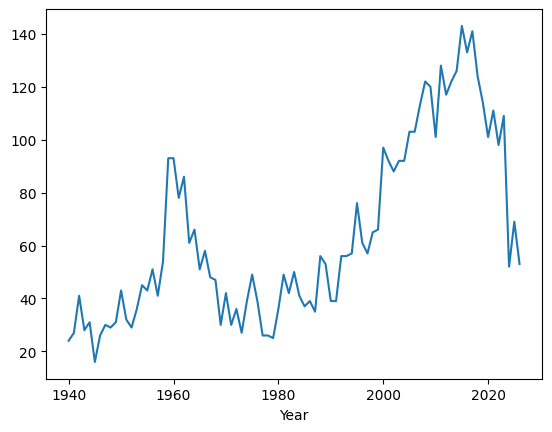

In [166]:
# 3. Look at year variable
print(df_cleaned['Year'].unique())
print(df_cleaned['Year'].dtype) # stored as float64

df_since1940 = df_cleaned[df_cleaned['Year'] >= 1940]
print(df_since1940['Year'].unique())
# Count amount of counts each year
attacks_per_year = df_since1940['Year'].value_counts().sort_index() # Counts attacks in chrono order
attacks_per_year.plot() # Better visualization of data, shows increasing from 1980-2015

The years range from 0 to 2026 with at least one missing value and a couple very old years that are less than 100. The attacks had a spike around 1960 and then steadily increased from around 1980 to 2015. Since around 2015, we have seen a decrease in shark attacks.


[nan 43. 27. 71. 21. 69. 31. 13. 12. 17. 35. 19. 11. 20. 38. 39. 16. 22.
 55. 26. 56. 24. 25. 61. 40. 14. 54. 48. 57.  8. 63.  9.  7. 85. 18. 66.
 37. 42. 45. 30. 60. 29. 58. 36. 23. 28. 68. 33. 15. 41. 49. 46. 65. 64.
 32. 10. 62. 52. 44. 47. 59. 50. 34. 77. 73. 67.  6. 53. 51. 75. 70.  4.
 74.  3. 82. 72.  5. 86. 84. 87.  1. 81. 78.]
float64


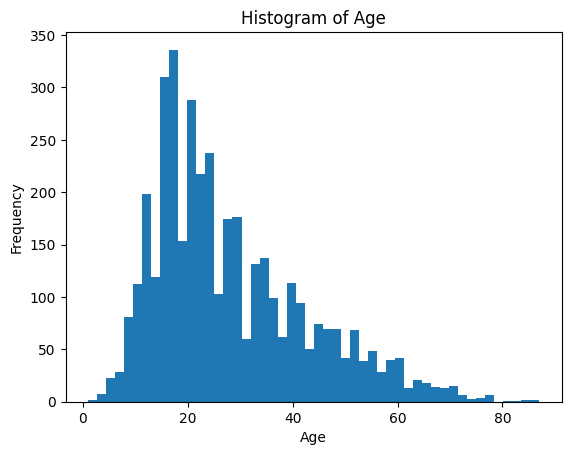

In [167]:
# 4. Clean Age variable
df_cleaned['Age'] = pd.to_numeric(df_cleaned['Age'], errors='coerce') # change from object to numeric
print(df_cleaned['Age'].unique())
print(df_cleaned['Age'].dtype)

# Plot histogram
df_cleaned['Age'].plot.hist(bins=50)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Histogram of Age')
plt.show()

In [168]:
# 5. Calculating proportion of male victims
print(df_cleaned['Sex'].unique())
# Clean variable so proprtion is taken from data where Sex is known
df_cleaned['Sex'] = df_cleaned['Sex'].str.strip().str.upper()
valid_sex = ['M', 'F', 'M F', 'M X 2']
df_sex = df_cleaned[df_cleaned['Sex'].isin(valid_sex)]
print(df_sex['Sex'].unique())

# Count number of male and female victims and store them
sex_counts = df_sex['Sex'].value_counts()
male_count = int(sex_counts.get('M', 0) + 2*sex_counts.get('M X 2', 0) + sex_counts.get('M F', 0))
female_count = int(sex_counts.get('F', 0) + sex_counts.get('M F', 0))
total_count = male_count + female_count

# Calculate proportion of male victims
male_proportion = male_count / total_count
print('Proportion of male victims:', male_proportion) # aka 87.47%

['F' 'M' 'M ' 'M F' '?' 'F ' nan ' M' 'm' 'lli' 'M x 2' 'N' '.']
['F' 'M' 'M F' 'M X 2']
Proportion of male victims: 0.8746748278500383


In [180]:
# 6. Clean Type Variable
print(df_cleaned['Type'].unique())
df_cleaned['Type'] = df_cleaned['Type'].str.strip().str.upper()
df_cleaned_type = df_cleaned['Type'].replace({
    'PROVOKED' : 'Provoked',
    'UNPROVOKED' : 'Unprovoked',
    'QUESTIONABLE' : 'Unknown',
    'WATERCRAFT' : 'Unknown',
    'SEA DISASTER' : 'Unknown',
    'UNCONFIRMED' : 'Unknown',
    '?' : 'Unknown',
    'UNVERIFIED' : 'Unknown',
    'INVALID' : 'Unknown',
    'UNDER INVESTIGATION' : 'Unknown',
    'BOAT' : 'Unknown',
    })
df_cleaned_type = df_cleaned_type.fillna('Unknown')
print(df_cleaned_type.unique())

print('Proportion of unprovoked attacks:', 5263/df_cleaned_type.value_counts().sum())

['UNPROVOKED' 'PROVOKED' 'QUESTIONABLE' 'WATERCRAFT' 'SEA DISASTER' nan
 '?' 'UNCONFIRMED' 'UNVERIFIED' 'INVALID' 'UNDER INVESTIGATION' 'BOAT']
['Unprovoked' 'Provoked' 'Unknown']
Proportion of unprovoked attacks: 0.7394969790642124


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [170]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]